# Imports

In [837]:
import pandas as pd
import numpy as np
import os
import torch
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
tqdm.pandas()

from data import create_saluki_dataloaders
from model import SalukiModel

def r2_coeff_determination(preds: np.ndarray, targets: np.ndarray) -> float:
    """R^2 = 1 - SS_res/SS_tot, matching train.py's ``r2_score``."""
    ss_res = np.sum((targets - preds) ** 2)
    ss_tot = np.sum((targets - targets.mean()) ** 2)
    return float(1.0 - ss_res / (ss_tot + 1e-8))

from scipy.stats import pearsonr, spearmanr
def pearson(x, y):
    r = pearsonr(x, y)[0]
    return round(r, 4)
def spearman(x, y):
    r = spearmanr(x, y)[0]
    return round(r, 4)
def sign_concordance(x, y):
    assert len(x) == len(y)
    return float(np.sum((x * y) > 0) / len(x))

def print_metrics_heldout(x, y):
    print(f"Pearson: {pearson(x, y):.4f}")
    print(f"Spearman: {spearman(x, y):.4f}")
    print(f"r2 (sklearn): {r2_score(x, y):.4f}")
    print(f"r2: {r2_coeff_determination(x, y):.4f}")
    print(f"RMSE: {root_mean_squared_error(x, y):.4f}")

### species token archutecture

In [838]:
# import torch
# import torch.nn as nn
# import torch.nn.functional as F

# def stochastic_shift(seq, shift_max=3, pad_value=0):
#     """Randomly shift a (batch, length, depth) sequence right by 0..shift_max,
#     padding the 5' end with zeros. Mirrors basenji StochasticShift(symmetric=False).
#     Uses torch's RNG so it stays reproducible under torch.manual_seed."""
#     shift = torch.randint(0, shift_max + 1, ()).item()   # one shift for the whole batch
#     if shift == 0:
#         return seq
#     pad = seq.new_full((seq.size(0), shift, seq.size(2)), pad_value)
#     return torch.cat([pad, seq[:, :-shift, :]], dim=1)    # prepend pad, drop the 3' tail

# class SalukiModel(nn.Module):
#     """
#     PyTorch implementation of the Saluki RNA half-life prediction model.

#     DOCUMENTATION OF ASSUMPTIONS ON EXTERNAL CODE (Data Loader):
#     -------------------------------------------------------------------------
#     1. Tensor Shape: Assumes the input tensor shape from the dataloader is 
#        `(batch_size, 12288, 6)`. The length is 12288, and depth 6 corresponds 
#        to 4 one-hot nucleotide channels + 2 binary tracks (first reading frame 
#        and 5' splice sites). This is permuted internally to `(batch_size, 6, 12288)`
#        to be compatible with PyTorch's Conv1d.
#     2. Sequence Padding: Assumes sequences shorter than 12288 are padded at the 
#        3' end (the right side of the sequence). This is crucial because the GRU 
#        processes the sequence right-to-left (from padding towards the 5' end), 
#        ensuring the information-dense 5' end is processed last and determines the 
#        final hidden state.
#     3. Multi-species Handling: Assumes there are multiple dataloaders (one per species) 
#        and each batch contains exactly one species. The `forward` pass takes an 
#        optional `species_index` to route the batch representation through the correct 
#        output head.

#     DOCUMENTATION OF ARCHITECTURE/IMPLEMENTATION CHANGES FROM TENSORFLOW:
#     -------------------------------------------------------------------------
#     1. Dimension Ordering: Keras Conv1D uses `(batch, length, channels)` while 
#        PyTorch Conv1d uses `(batch, channels, length)`. We permute the dimensions 
#        after the input layer and appropriately before/after LayerNorm.
#     2. LayerNormalization: PyTorch's LayerNorm expects the normalized dimension 
#        to be the last dimension. We apply it by permuting the tensor back to 
#        `(batch, length, channels)`, applying LayerNorm across channels, and permuting back.
#     3. GRU `go_backwards`: Keras GRU supports `go_backwards=True` natively. In PyTorch, 
#        we emulate this by flipping the sequence along the time dimension `torch.flip(x, dims=[1])` 
#        before passing it to the GRU, and extracting the final output state.
#     4. Dense Layers: Keras `Dense` is directly replaced by PyTorch `Linear`.
#     5. BatchNorm momentum: Keras and PyTorch define BatchNorm momentum as opposites
#        (Keras: running = m*running + (1-m)*batch; PyTorch: running = (1-m)*running + m*batch).
#        `bn_momentum` here is the *Keras* value from params.json (0.90); we convert it
#        internally with `1 - bn_momentum`. We also set `eps=1e-3` to match Keras'
#        BatchNormalization default (PyTorch's default is 1e-5).
#     6. Weight initialization: Keras used `he_normal` for every kernel. We replicate
#        this in `_init_weights` (Kaiming-normal for Conv/Linear and the GRU input
#        kernel, orthogonal for the GRU recurrent kernel, zeros for all biases).
#     7. L2 regularization: Keras applied `kernel_regularizer=l2(l2_scale)` to the conv
#        kernels, the GRU *input* kernel, and the penultimate dense -- but NOT to the
#        output heads, biases, norm params, or the GRU recurrent kernel. `l2_loss()`
#        reproduces exactly that penalty for the trainer to add to the loss.
#     8. Data augmentation: Keras wrapped the input in StochasticShift(augment_shift,
#        symmetric=False), which during training shifts the sequence right by a random
#        0..augment_shift positions (params.json: 3), padding the 5' end with zeros.
#        `stochastic_shift()` reproduces this; it runs only when `self.training` is set.
#     """
#     def __init__(self, seq_length=12288, seq_depth=6, filters=64, kernel_size=5,
#                  dropout=0.3, num_layers=6, heads=2, ln_epsilon=0.007,
#                  bn_momentum=0.90, bn_epsilon=1e-3, l2_scale=0.001, augment_shift=3):
#         super(SalukiModel, self).__init__()
#         self.seq_length = seq_length
#         self.seq_depth = seq_depth
#         self.filters = filters
#         self.l2_scale = l2_scale
#         self.augment_shift = augment_shift

#         # Convert the Keras-style BatchNorm momentum (params.json: 0.90) to PyTorch's
#         # convention: 0.90 -> 0.10. See note 5 in the class docstring.
#         torch_bn_momentum = 1.0 - bn_momentum

#         # Initial Convolution
#         self.initial_conv = nn.Conv1d(in_channels=seq_depth, out_channels=filters, 
#                                       kernel_size=kernel_size, bias=False)
        
#         # Middle Convolutions
#         self.middle_blocks = nn.ModuleList()
#         for _ in range(num_layers):
#             block = nn.ModuleDict({
#                 'ln': nn.LayerNorm(filters, eps=ln_epsilon),
#                 'conv': nn.Conv1d(in_channels=filters, out_channels=filters, kernel_size=kernel_size),
#                 'dropout': nn.Dropout(p=dropout),
#                 'pool': nn.MaxPool1d(kernel_size=2)
#             })
#             self.middle_blocks.append(block)
            
#         # Aggregate Sequence (GRU)
#         self.gru_ln = nn.LayerNorm(filters, eps=ln_epsilon)
#         # Note: input to GRU will be (batch, seq_len, input_size)
#         self.gru = nn.GRU(input_size=filters, hidden_size=filters, batch_first=True)
        
#         # Penultimate Dense
#         self.penultimate_bn = nn.BatchNorm1d(num_features=filters, momentum=torch_bn_momentum, eps=bn_epsilon)
#         self.penultimate_dense = nn.Linear(filters, filters)
#         self.penultimate_dropout = nn.Dropout(p=dropout)

#         # Final Representation
#         self.final_bn = nn.BatchNorm1d(num_features=filters, momentum=torch_bn_momentum, eps=bn_epsilon)

#         # Output Heads (For N species)
#         self.output_heads = nn.ModuleList([nn.Linear(filters, 1) for _ in range(heads)])

#         # FiLM
#         # self.species_token_emb = nn.Sequential(
#         #     nn.Linear(8, 32),
#         #     nn.GELU(),
#         #     nn.Dropout(0.1),
#         #     nn.Linear(32, 2*filters)
#         # )

#         # FiLM bias-only
#         # self.species_token_emb = nn.Sequential(
#         #     nn.Linear(8, 32),
#         #     nn.GELU(),
#         #     nn.Dropout(0.1),
#         #     nn.Linear(32, filters)
#         # )

#         # Species token "AG-style"
#         self.species_token_emb = nn.Embedding(heads, filters)

#         # Match Keras 'he_normal' kernel initialization across all layers.
#         self._init_weights()

#     def _init_weights(self):
#         """Replicate Keras' `he_normal` kernel init (note 6 in the class docstring)."""
#         for m in self.modules():
#             if isinstance(m, (nn.Conv1d, nn.Linear)):
#                 # he_normal == Kaiming-normal for a ReLU non-linearity.
#                 nn.init.kaiming_normal_(m.weight, nonlinearity='relu')
#                 if m.bias is not None:
#                     nn.init.zeros_(m.bias)
#             elif isinstance(m, nn.GRU):
#                 for name, p in m.named_parameters():
#                     if 'weight_ih' in name:      # input kernel -> he_normal
#                         nn.init.kaiming_normal_(p, nonlinearity='relu')
#                     elif 'weight_hh' in name:    # recurrent kernel -> Keras GRU default
#                         nn.init.orthogonal_(p)
#                     elif 'bias' in name:
#                         nn.init.zeros_(p)

#     def l2_loss(self):
#         """
#         L2 penalty matching Keras `kernel_regularizer=l2(l2_scale)`.

#         Keras adds `l2_scale * sum(w**2)` to the loss for the regularized kernels only:
#         the conv kernels, the GRU *input* kernel, and the penultimate dense -- NOT the
#         output heads, biases, norm params, or the GRU recurrent kernel. The trainer adds
#         the returned value to the data loss before `backward()`.
#         """
#         if self.l2_scale == 0:
#             return self.initial_conv.weight.new_zeros(())
#         reg = self.initial_conv.weight.pow(2).sum()
#         for block in self.middle_blocks:
#             reg = reg + block['conv'].weight.pow(2).sum()
#         reg = reg + self.gru.weight_ih_l0.pow(2).sum()
#         reg = reg + self.penultimate_dense.weight.pow(2).sum()
#         return self.l2_scale * reg

#     # def forward(self, x, species_token=None, species_index=0):
#     def forward(self, x, species_index=0):
#         # x shape: (batch_size, 12288, 6)

#         # Training-only data augmentation (Keras StochasticShift). self.training is
#         # toggled by model.train()/model.eval(), matching the original `if training:`.
#         # Applied while still (batch, length, channels) so the length axis is dim=1.
#         if self.training and self.augment_shift:
#             x = stochastic_shift(x, shift_max=self.augment_shift)

#         # FiLM
#         # species_weight, species_bias = self.species_token_emb(species_token).chunk(2, dim=-1)
#         # species_weight = species_weight.unsqueeze(-1)
#         # species_bias = species_bias.unsqueeze(-1)

#         # Bias-only FiLM
#         # species_bias = self.species_token_emb(species_token)
#         # species_bias = species_bias.unsqueeze(-1)

#         # "AG-style"
#         species_bias = self.species_token_emb(
#             torch.tensor([species_index], dtype=torch.long, device=x.device)
#         )
#         species_bias = species_bias.unsqueeze(1)

#         # Permute to (batch_size, 6, 12288) for Conv1d
#         x = x.permute(0, 2, 1)
        
#         # Initial Convolution
#         x = self.initial_conv(x)
#         # x *= species_token
        
#         # Middle convolutions
#         for block in self.middle_blocks:
#             # LayerNorm over channels: needs (batch, length, channels)
#             x = x.permute(0, 2, 1)
#             x = block['ln'](x)
#             x = x.permute(0, 2, 1) # Back to (batch, channels, length)
            
#             # print('DEBUG: ', x.shape)
#             x = F.relu(x)
#             x = block['conv'](x)
#             x = block['dropout'](x)
#             x = block['pool'](x)
            
#         # Aggregate Sequence
#         # Transpose back for LayerNorm and GRU
#         x = x.permute(0, 2, 1) # (batch, length, channels)
#         x = self.gru_ln(x)
#         # print(f"DEBUG_TOKEN: {x.shape}, {species_bias.shape}")
#         x = x + species_bias
#         x = F.relu(x)
        
#         # GRU go_backwards logic: flip along the sequence length dimension (dim=1)
#         x_flipped = torch.flip(x, dims=[1])
        
#         # Pass to GRU
#         gru_out, hidden = self.gru(x_flipped)
#         # We want the output at the final timestep (which corresponds to the 5' end of the transcript)
#         # gru_out is (batch, seq_len, hidden_size)
#         x = gru_out[:, -1, :] # (batch, hidden_size)
        
#         # Penultimate Dense
#         x = self.penultimate_bn(x)
#         x = F.relu(x)
#         x = self.penultimate_dense(x)
#         x = self.penultimate_dropout(x)
        
#         # Final Representation
#         x = self.final_bn(x)
#         x = F.relu(x)
        
#         # Output Head Selection
#         # Assuming the entire batch corresponds to a single species
#         head = self.output_heads[species_index]
#         prediction = head(x)
        
#         return prediction


### model init

In [839]:
# checkpoint_path = '/s/project/ml4rg_students/2026/project03/project-half-life/outputs/out_setup/19470366_06-16-13-06/model_best_19470366_06-16-13-06.pt'
# checkpoint_path = '/Users/neverovaleksandr/saluki/project-half-life/outputs/out_setup_1sp/local_07-11-16-54/model_best_local_07-11-16-54.pt'

# converted
# checkpoint_path = '/Users/neverovaleksandr/saluki/project03/project-half-life/pytorch_weights_converted_upd.pkl'

# # 2 species
# checkpoint_path = '/Users/neverovaleksandr/saluki/project03/project-half-life/outputs/out_setup_2/19470871_06-16-15-52/model_best_19470871_06-16-15-52.pt'

# 13 species baseline
# checkpoint_path = '/Users/neverovaleksandr/saluki/project03/project-half-life/outputs/out_setup_13sp/19509600_06-25-11-50/model_best_19509600_06-25-11-50.pt'

# # 13 species best hyperparams
# checkpoint_path = ''

# 13 species species-weighted
# checkpoint_path = '/Users/neverovaleksandr/saluki/project03/project-half-life/outputs/out_13sp_weight_05/19590828_07-06-13-52/model_best_19590828_07-06-13-52.pt'

# 13 species species token
# checkpoint_path = '/Users/neverovaleksandr/saluki/project-half-life/out_setup_13sp_run_sp_token_emb_AG_style/model_best_19603993_07-13-15-56.pt'

# # 7 species baseline
# checkpoint_path = '/Users/neverovaleksandr/saluki/project03/project-half-life/outputs/out_setup_7sp/19598959_07-07-15-07/model_best_19598959_07-07-15-07.pt'

# # 7 species species-token
# checkpoint_path = '/Users/neverovaleksandr/saluki/project-half-life/out_setup_7sp_run_sp_token_emb_AG_style/model_best_19603912_07-13-12-39.pt'

# Human-only
checkpoint_path = '/Users/neverovaleksandr/saluki/project-half-life/outputs/out_setup_1sp/local_07-11-16-54/model_best_local_07-11-16-54.pt'

# Best Adam
# checkpoint_path = '/Users/neverovaleksandr/saluki/19603910_07-13-12-35_Batch128_LR_0.00014407_Wdecay_0,00001217_AdamW/19603909_07-13-12-34_Batch_128_LR_0,00014407_Adam/model_best_19603909_07-13-12-34.pt'

# Best AdamW
# checkpoint_path = '/Users/neverovaleksandr/saluki/19603910_07-13-12-35_Batch128_LR_0.00014407_Wdecay_0,00001217_AdamW/19603910_07-13-12-35_Batch128_LR_0.00014407_Wdecay_0,00001217_AdamW/model_best_19603910_07-13-12-35.pt'

# Ensembl
# ensembl_i = 1
# checkpoint_path = '/Users/neverovaleksandr/saluki/ensemble_/ensemble_1_model_best_local_07-11-01-33.pt'

# ensembl_i = 2
# checkpoint_path = '/Users/neverovaleksandr/saluki/ensemble_/ensemble_2_model_best_local_07-11-10-22.pt'

# ensembl_i = 4
# checkpoint_path = '/Users/neverovaleksandr/saluki/ensemble_/ensemble_4_model_best_local_07-12-00-59.pt'

# ensembl_i = 5
# checkpoint_path = '/Users/neverovaleksandr/saluki/ensemble_/ensemble_5_model_best_local_07-12-15-00.pt'

# ensembl_i = 6
# checkpoint_path = '/Users/neverovaleksandr/saluki/ensemble_/ensemble_6_model_best_local_07-13-01-06.pt'

In [840]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cuda'
# device = 'cpu'
print(device)

mps


In [841]:
model = SalukiModel(heads=1)
if 'weights_converted' in checkpoint_path:
    import pickle
    with open(checkpoint_path, "rb") as f:
        checkpoint = pickle.load(f)
    for key in checkpoint.keys():
        checkpoint[key] = torch.from_numpy(checkpoint[key])
    model.load_state_dict(checkpoint)
else:
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True, map_location=device))
model.eval()
model.to(device)

SalukiModel(
  (initial_conv): Conv1d(6, 64, kernel_size=(5,), stride=(1,), bias=False)
  (middle_blocks): ModuleList(
    (0-5): 6 x ModuleDict(
      (ln): LayerNorm((64,), eps=0.007, elementwise_affine=True, bias=True)
      (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
      (dropout): Dropout(p=0.3, inplace=False)
      (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (gru_ln): LayerNorm((64,), eps=0.007, elementwise_affine=True, bias=True)
  (gru): GRU(64, 64, batch_first=True)
  (penultimate_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, bias=True, track_running_stats=True)
  (penultimate_dense): Linear(in_features=64, out_features=64, bias=True)
  (penultimate_dropout): Dropout(p=0.3, inplace=False)
  (final_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, bias=True, track_running_stats=True)
  (output_heads): ModuleList(
    (0): Linear(in_features=64, out_features=1, bi

# Eval on held-out

In [807]:
train_data, eval_data, test_data = create_saluki_dataloaders(
    species_tsvs={
        "human": "../project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv",
        "mouse": "../project03/toga_13_species_updated/saluki_mouse.mm10.mm10.tsv"},
    species_order=['human', 'mouse'],
    batch_size=64,
    seq_length=12288,
    num_workers=0,
    drop_last=False,
    include_test=True
) 

## Human

In [842]:
species = 'human'

species_map = {
    'human': 0,
    'mouse': 1,
}
species_i = species_map[species]

In [843]:
all_outputs, all_targets = [], []

with torch.no_grad():
    # here change to test in two places
    # for x, y_true in tqdm(eval_data[species_i], total=len(eval_data[species_i])):
    for x, y_true in tqdm(test_data[species_i], total=len(test_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x, species_index=species_i)
    
        all_targets.append(y_true.clone().squeeze())
        all_outputs.append(y_pred.cpu().clone().squeeze())

all_outputs, all_targets = torch.hstack(all_outputs), torch.hstack(all_targets)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  8.17it/s]


In [844]:
print_metrics_heldout(all_outputs.numpy(), all_targets.numpy())

Pearson: 0.7450
Spearman: 0.7424
r2 (sklearn): 0.4261
r2: 0.5116
RMSE: 3.4419


### Plots

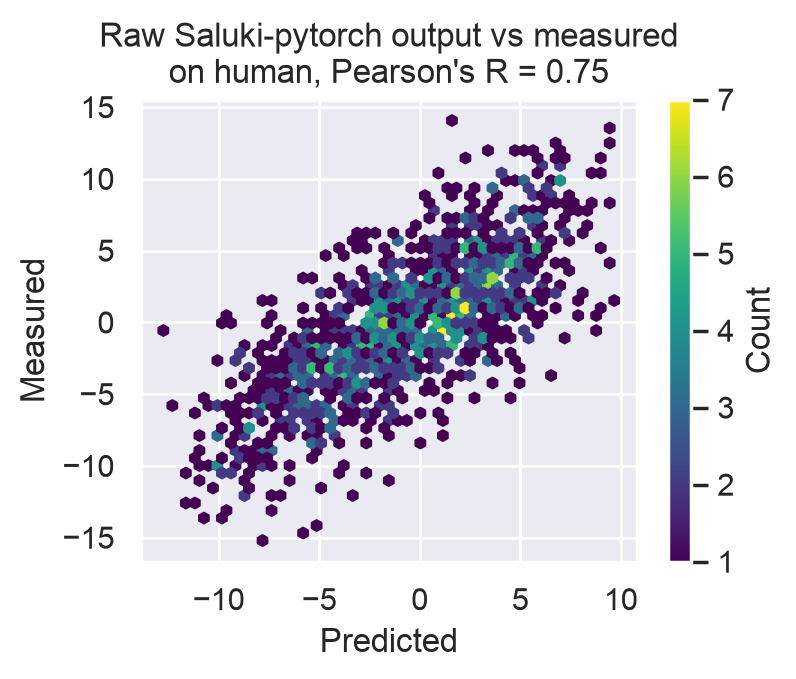

In [195]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    all_outputs,
    all_targets,
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki-pytorch output vs measured\non {species}, Pearson's R = {pearson(all_outputs, all_targets):.2f}")
plt.show()

In [196]:
df_toga = pd.read_table('../saluki_toga/saluki_human.hg38.hg38.tsv')

In [197]:
df_toga_val = df_toga[df_toga['fold'] == 0].copy()

In [198]:
df_toga_val['saluki_pytorch_pred'] = all_outputs

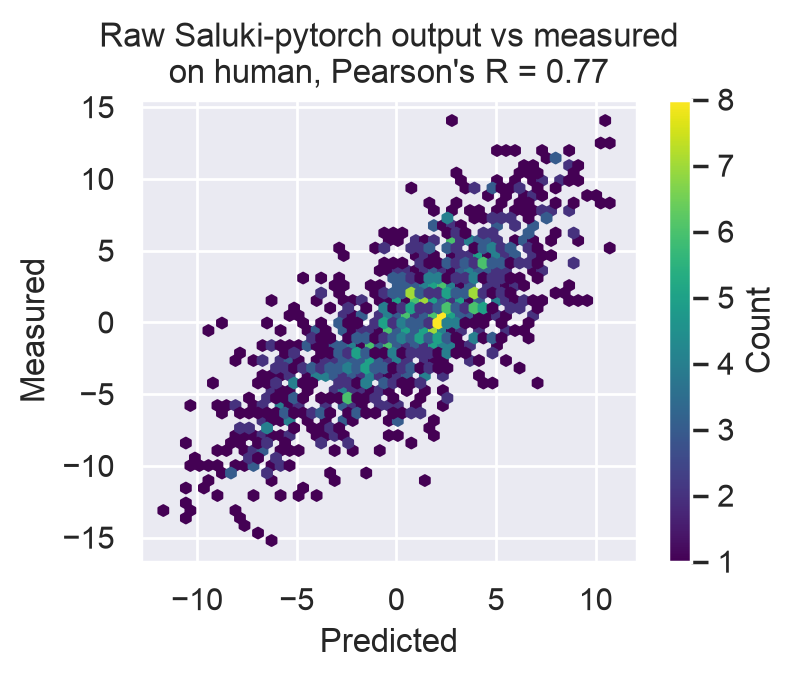

In [153]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    df_toga_val['saluki_pytorch_pred'],
    df_toga_val['half_life'],
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki-pytorch output vs measured\non {species}, Pearson's R = {pearson(all_outputs, all_targets):.2f}")
plt.show()

In [99]:
df_val_genes = pd.read_csv("../project03/project-half-life/results/test_genes.csv")

In [100]:
df_toga_val = df_toga_val.rename(columns={'gene': 'Gene'})

In [101]:
df_j = df_val_genes.set_index('Gene').join(
    df_toga_val.set_index('Gene')['saluki_pytorch_pred'], how='inner'
).reset_index()

In [102]:
df_j.shape

(1268, 8)

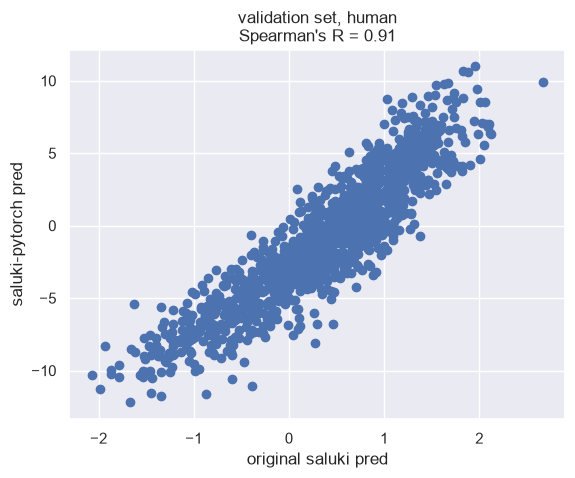

In [103]:
plt.scatter(df_j['orig_saluki_pred'], df_j['saluki_pytorch_pred'])
plt.xlabel('original saluki pred')
plt.ylabel('saluki-pytorch pred')
plt.title(f"validation set, human\nSpearman's R = {spearman(df_j['orig_saluki_pred'], df_j['saluki_pytorch_pred']):.2f}")
plt.show()

In [104]:
# df_all_joined = df_j.copy().rename(columns={'saluki_pytorch_pred': 'saluki_pytorch_pred_converted'})
df_all_joined = df_j.copy()

In [105]:
# df_all_joined = df_all_joined.set_index('Gene').join(
#     df_j.set_index('Gene')[['saluki_pytorch_pred']].rename(columns={'saluki_pytorch_pred': 'saluki_pytorch_pred_species'})
# ).reset_index()

In [106]:
df_all_joined

,Gene,Unnamed: 0,Fold,Stability,Length,Split,orig_saluki_pred,saluki_pytorch_pred
0,ENSG00000000457,0,0,-1.437941,3090,test,0.168403,-0.681699
1,ENSG00000001631,1,0,-0.184992,4762,test,0.084816,-1.670531
2,ENSG00000002549,2,0,1.395107,2213,test,1.185084,5.738979
3,ENSG00000003137,3,0,-0.657063,4732,test,0.714989,-2.724142
4,ENSG00000003987,4,0,0.064368,3850,test,0.377958,-1.782976
...,...,...,...,...,...,...,...,...
1263,ENSG00000270765,1291,0,-0.118856,3014,test,-0.553595,-6.429271
1264,ENSG00000273820,1293,0,-2.312767,2618,test,-1.782840,-10.424508
1265,ENSG00000276293,1294,0,0.152546,5734,test,1.113425,4.325259
1266,ENSG00000277149,1295,0,-0.920043,3113,test,0.754864,-0.698450


In [107]:
df_all_joined.shape

(1268, 8)

In [110]:
df_toga = pd.read_table('../saluki_toga/saluki_human.hg38.hg38.tsv').rename(columns={'gene': 'Gene'})

In [111]:
df_all_joined = df_all_joined.set_index('Gene').join(
    df_toga.set_index('Gene')[['half_life']]
).reset_index()

## Mouse

In [824]:
species = 'mouse'

species_map = {
    'human': 0,
    'mouse': 1,
}
species_i = species_map[species]
species_i

1

In [825]:
all_outputs, all_targets = [], []

with torch.no_grad():
    # here change to test in two places
    # for x, y_true in tqdm(eval_data[species_i], total=len(eval_data[species_i])):
    for x, y_true in tqdm(test_data[species_i], total=len(test_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x, species_index=species_i)
    
        all_targets.append(y_true.clone().squeeze())
        all_outputs.append(y_pred.cpu().clone().squeeze())

all_outputs, all_targets = torch.hstack(all_outputs), torch.hstack(all_targets)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:02<00:00,  9.28it/s]


In [826]:
print_metrics_heldout(all_outputs.numpy(), all_targets.numpy())

Pearson: 0.7055
Spearman: 0.7019
r2 (sklearn): 0.0195
r2: 0.1841
RMSE: 3.3449


### Plots

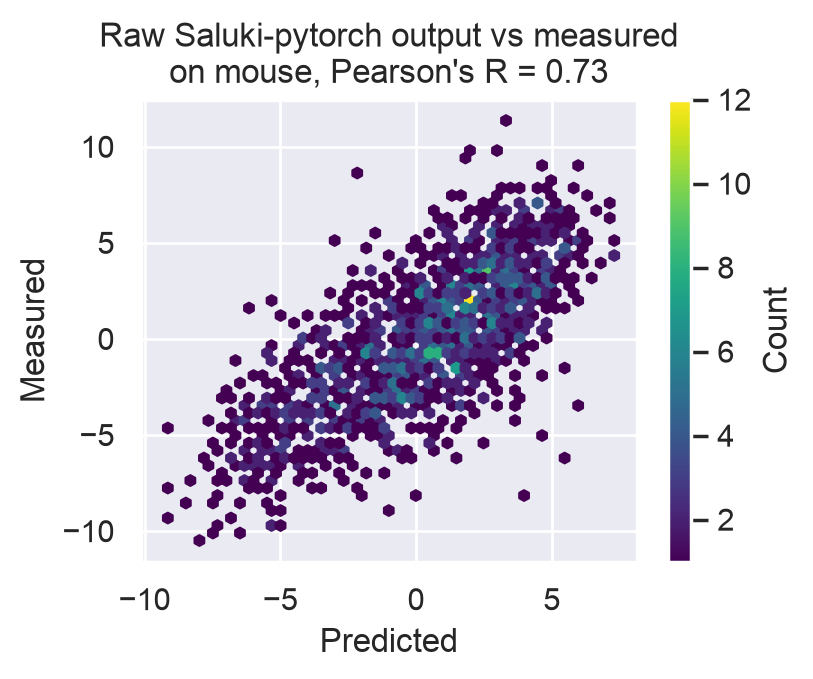

In [505]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    all_outputs,
    all_targets,
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki-pytorch output vs measured\non {species}, Pearson's R = {pearson(all_outputs, all_targets):.2f}")
plt.show()

In [507]:
df_toga = pd.read_table('../saluki_toga/saluki_mouse.mm10.mm10.tsv')

In [508]:
df_toga_val = df_toga[df_toga['fold'] == 0].copy()

In [509]:
df_toga_val['saluki_pytorch_pred'] = all_outputs

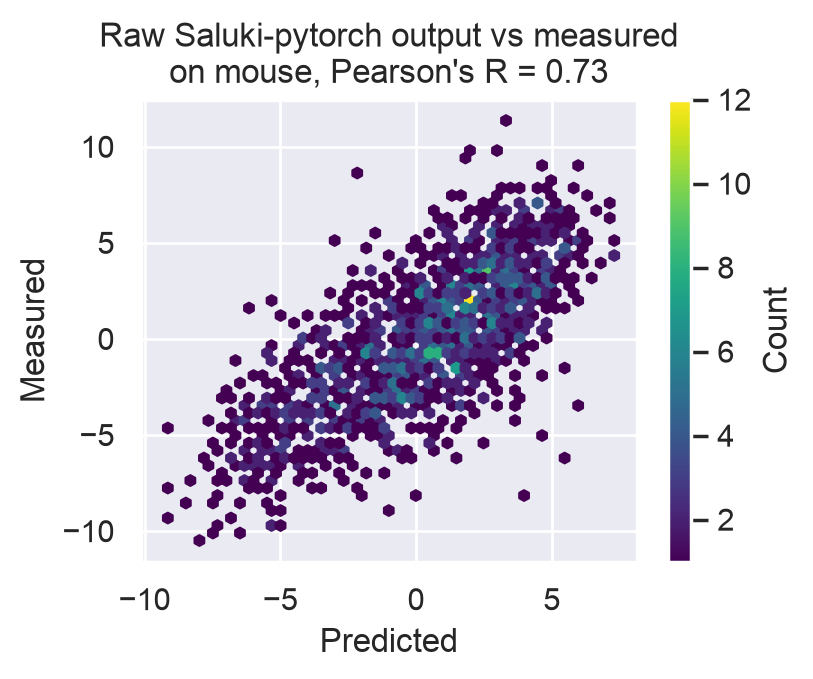

In [510]:
sns.set_theme()

plt.figure(figsize=(4, 3), dpi=200)

hb = plt.hexbin(
    df_toga_val['saluki_pytorch_pred'],
    df_toga_val['half_life'],
    gridsize=50,
    mincnt=1,
    cmap="viridis"
)

plt.colorbar(hb, label="Count")
plt.xlabel("Predicted")
plt.ylabel("Measured")
plt.title(f"Raw Saluki-pytorch output vs measured\non {species}, Pearson's R = {pearson(all_outputs, all_targets):.2f}")
plt.show()

In [511]:
df_val_genes = pd.read_csv("../project03/project-half-life/results/test_genes_mouse.csv")

In [512]:
df_toga_val = df_toga_val.rename(columns={'gene': 'Gene'})

In [517]:
df_j_mouse_preds = df_val_genes.set_index('Gene').join(
    df_toga_val.set_index('Gene')['saluki_pytorch_pred'], how='inner'
).reset_index()

# Eval on MPRA

## 3' UTR effect

In [726]:
from basenji import dna_io
MAXLEN = 12288

# sns.set_theme()

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.


In [727]:
mpra_data_path = '../project03/saluki_paper/Fig6_S7/Siegel_testSet/'

# cell_line = 'Jurkat'
cell_line = 'Beas2B'

In [728]:
df_reporter = pd.read_table(mpra_data_path+"BTV_construct.txt.gz", index_col=0, header=None, compression='gzip')
construct = df_reporter.values

df_mpras = pd.read_table(mpra_data_path+f"fastUTR_mpra.txt.gz", header=None, compression='gzip')
seq = df_mpras[[0]][0].values

In [729]:
aa_len = int(len(construct[1][0])/3)
coding = np.append(np.zeros(len(construct[0][0])), np.tile([1,0,0], aa_len))

reporter = construct[0]+construct[1]+construct[2]

df_perf = {
    'seq': [],
    'pred': []
}

with torch.no_grad():
    for i in tqdm(seq): # iterate through all sequences
        batch = np.zeros((1,MAXLEN,6))
        myseq = (reporter+i+construct[3])[0]
        batch[0,0:len(myseq),0:4] = dna_io.dna_1hot(myseq)
        batch[0,0:len(coding),4] = coding
        batch = torch.from_numpy(batch).float().to(device)
        pred = model(batch)
        df_perf['seq'].append(i)
        df_perf['pred'].append(pred[0][0].cpu().numpy())

df_perf = pd.DataFrame(df_perf)

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 31054/31054 [07:46<00:00, 66.58it/s]


In [730]:
df_res_publ = pd.read_table(mpra_data_path+f'fastUTR_MPRA_predictions{suffix}.txt.gz', compression='gzip')
# df_targets = pd.read_table(mpra_data_path+'fastUTR_mpra.txt.gz', compression='gzip', header=None)
df_mpras = df_mpras.rename(columns={0: 'seq', 1: 'measured_jurkat', 2: 'measured_beas2b'})

In [731]:
df_perf['pred'] = df_perf['pred'].astype(float)

In [732]:
df_perf_orig = pd.read_csv('../project03/orig_saluki_Siegel_testSet_pred.csv', sep='\t')

In [733]:
df_j = df_perf.set_index('seq').drop_duplicates().join(
    df_perf_orig.set_index('seq').drop_duplicates(), how='inner', rsuffix='_orig'
).reset_index()

In [734]:
df_j_targ = df_perf.set_index('seq').drop_duplicates().join(
    df_mpras.set_index('seq').drop_duplicates(), how='inner'
).reset_index()

In [735]:
df_j_targ_publ = df_res_publ.set_index('seq').drop_duplicates().join(
    df_mpras.set_index('seq').drop_duplicates(), how='inner'
).reset_index()

In [736]:
df_j_targ_orig = df_perf_orig.set_index('seq').drop_duplicates().join(
    df_mpras.set_index('seq').drop_duplicates(), how='inner'
).reset_index()

In [737]:
df_j.shape, df_j_targ.shape, df_j_targ_orig.shape

((31004, 3), (31037, 4), (31021, 4))

In [738]:
df_j_targ.columns

Index(['seq', 'pred', 'measured_jurkat', 'measured_beas2b'], dtype='str')

In [739]:
df_jurkat_utr = df_j_targ[['seq', 'pred', 'measured_jurkat']].dropna()
df_beas2b_utr = df_j_targ[['seq', 'pred', 'measured_beas2b']].dropna()

In [740]:
df_beas2b_utr.shape, df_jurkat_utr.shape

((7610, 3), (30236, 3))

## VEP

In [830]:
from matplotlib.colors import LinearSegmentedColormap

cmap = LinearSegmentedColormap.from_list(
    "grey_blue_red_yellow",
    ["#CCCAC8", "#000080", "#0000ff", "#ff0000", "#ff8000", "#ffff00"]
)

In [831]:
from basenji import dna_io
MAXLEN = 12288

# sns.set_theme()

In [832]:
mpra_data_path = '../project03/saluki_paper/Fig6_S7/Siegel_testSet/'

# cell_line = 'Jurkat'
cell_line = 'Beas2B'
# cell_line = "3'-UTR"

suffix = '_' + cell_line if cell_line != "3'-UTR" else ''

In [833]:
df_reporter = pd.read_table(mpra_data_path+"BTV_construct.txt.gz", index_col=0, header=None, compression='gzip')
construct = df_reporter.values

df_mpras = pd.read_table(mpra_data_path+f"fastUTR_mpra{suffix}.txt.gz", header=None, compression='gzip')
sequences_mpra = df_mpras[[0]][0].values

In [834]:
aa_len = int(len(construct[1][0])/3)
coding = np.append(np.zeros(len(construct[0][0])), np.tile([1,0,0], aa_len))

reporter = construct[0]+construct[1]+construct[2]

if 2 in df_mpras.columns:
    df_mpras = df_mpras.rename(columns={0: 'seq', 1: 'measured_jurkat', 2: 'measured_beas2b'})
else:
    df_mpras = df_mpras.rename(columns={0: 'seq', 1: 'measured'})

In [835]:
def print_mpra_vep_metrics(x, y):
    print(f"Spearman: {spearman(x, y):.4f}")
    print(f"Sign concordance: {sign_concordance(x, y):.4f}")

In [836]:
df_perf = {
    'seq': [],
    'pred': []
}

with torch.no_grad():
    for i in tqdm(sequences_mpra): # iterate through all sequences
        batch = np.zeros((1, MAXLEN, 6))
        myseq = (reporter+i+construct[3])[0]
        batch[0,0:len(myseq),0:4] = dna_io.dna_1hot(myseq)
        batch[0,0:len(coding),4] = coding
        batch = torch.from_numpy(batch).float().to(device)
        pred = model(batch, species_index=0)
        df_perf['seq'].append(i)
        df_perf['pred'].append(pred[0][0].cpu().numpy())
df_perf = pd.DataFrame(df_perf)
seq = df_perf["seq"].iloc[::2]

alt = df_perf["pred"].iloc[::2].to_numpy()
ref = df_perf["pred"].iloc[1::2].to_numpy()

df_delta = pd.DataFrame({
    "seq": seq,
    "ref": ref,
    "alt": alt,
    "delta": alt - ref
})
df_j = df_delta.set_index('seq').join(
    df_mpras.set_index('seq')
).rename(columns = {
    'delta': 'delta_pred_pytorch'
}).reset_index()
df_j['delta_pred_pytorch'] = df_j['delta_pred_pytorch'].astype(float)
df_j['measured'] = df_j['measured'].astype(float)
mpra_r_s = spearman(df_j['delta_pred_pytorch'], df_j['measured'])
mpra_r_p = pearson(df_j['delta_pred_pytorch'], df_j['measured'])
mpra_r_sc = sign_concordance(df_j['delta_pred_pytorch'], df_j['measured'])
print_mpra_vep_metrics(df_j['delta_pred_pytorch'], df_j['measured'])

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4462/4462 [01:08<00:00, 65.18it/s]

Spearman: 0.3229
Sign concordance: 0.6307


In [467]:
# df_j_ens = df_j.rename(columns={
#     'delta_pred_pytorch': f'delta_pred_pytorch_{ensembl_i}',
#     'ref': f"ref_{ensembl_i}",
#     'alt': f"alt_{ensembl_i}"
# })
df_j_ens = df_j_ens.set_index('seq').join(
    df_j.rename(columns={
        'delta_pred_pytorch': f'delta_pred_pytorch_{ensembl_i}',
        'ref': f"ref_{ensembl_i}",
        'alt': f"alt_{ensembl_i}"
    }).set_index('seq').drop(columns='measured')
).reset_index()

In [468]:
df_j_ens

,seq,ref_1,alt_1,delta_pred_pytorch_1,measured,ref_2,alt_2,delta_pred_pytorch_2,ref_4,alt_4,delta_pred_pytorch_4,ref_5,alt_5,delta_pred_pytorch_5,ref_6,alt_6,delta_pred_pytorch_6
0,CCGTTCACGTCTCTGCATCCATTCCTTCATGTCTTTATTTAGTTGT...,-2.186296,-0.970126,1.216170,-0.092268,-0.92554575,0.7084511,1.633997,-2.8560154,-1.803915,1.052100,-6.4177566,-5.4113965,1.006360,-6.015569,-4.9249234,1.090646
1,CCGTTCACGTCTCTGCATCCATTCCTTCATGTCTTTATCTAGTTGT...,-2.186296,0.5068339,2.693130,0.277942,-0.92554575,2.7365282,3.662074,-2.8560154,-0.87697756,1.979038,-6.4177566,-3.6778202,2.739936,-6.015569,-2.7400413,3.275528
2,CCGTCTCTACCAAACAGACAAAAAGCAGCCAGGCGTGGTGGCACAT...,-2.158533,-2.0907764,0.067757,0.159537,-0.73489755,-0.6681196,0.066778,-2.4438932,-2.4257617,0.018131,-5.2665243,-5.1720243,0.094500,-5.425344,-5.362393,0.062951
3,CCGTCTCTACCAGACAAAAAGCAGCCAGGCGTGGTGGCACATCTGT...,-2.158533,-2.165783,-0.007250,0.190078,-0.73489755,-0.39110637,0.343791,-2.4438932,-2.1930254,0.250868,-5.2665243,-5.2290263,0.037498,-5.425344,-5.445006,-0.019662
4,GGCTAATGAAGTGAGGGGAGGGAGGGATGTCACCCCAAAAGTAGGC...,-1.5372281,-1.1660466,0.371181,0.100250,-0.3854404,-0.28928986,0.096151,-2.6968143,-2.6325753,0.064239,-6.568716,-6.3793545,0.189362,-5.30181,-4.895009,0.406801
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2226,TAATGGGAACTCAAATGAATTTTAATAACTTACTTTGTACAAAACT...,-3.9339535,-0.59913325,3.334820,0.469906,-2.8806074,1.8457927,4.726400,-5.9416494,-2.2594512,3.682198,-8.628081,-5.628931,2.999150,-7.720488,-4.470776,3.249712
2227,TAATGGGAACTCAAATGAATTTTAATAACTTACTTTGTACAAAACT...,-3.9339535,-0.66703576,3.266918,0.334780,-2.8806074,1.928882,4.809489,-5.9416494,-2.3448281,3.596821,-8.628081,-5.7194543,2.908627,-7.720488,-4.3385677,3.381920
2228,CATATATCAAGTTCACCTGATAATTGTTAACTCTCAATTTCAGATT...,1.5568688,1.64392,0.087051,-0.051874,3.1004598,3.03432,-0.066140,-2.1478937,-1.9742347,0.173659,-4.749816,-4.0911937,0.658622,-2.3301227,-2.4388862,-0.108763
2229,AGACTAAATGCCTTATGCATCTGAGGAGATACACCGTAGGATTGTG...,-1.5172348,-0.04205385,1.475181,0.132570,0.25077638,1.6873513,1.436575,-2.0345397,-1.1447505,0.889789,-5.089993,-3.6718369,1.418156,-4.861268,-3.6809323,1.180336


In [491]:
df_j_ens['delta_pred_pytorch_ens_average_of_deltas'] = df_j_ens[[
    'delta_pred_pytorch_1',
    'delta_pred_pytorch_2',
    'delta_pred_pytorch_4',
    'delta_pred_pytorch_5',
    'delta_pred_pytorch_6',
]].mean(axis=1)

In [495]:
df_j_ens.to_csv('ensembl_mpra_vep_beas2b.csv')

In [680]:
print_mpra_vep_metrics(df_j_ens['delta_pred_pytorch_ens_average_of_deltas'], df_j_ens['measured'])

Spearman: 0.3598
Sign concordance: 0.6280


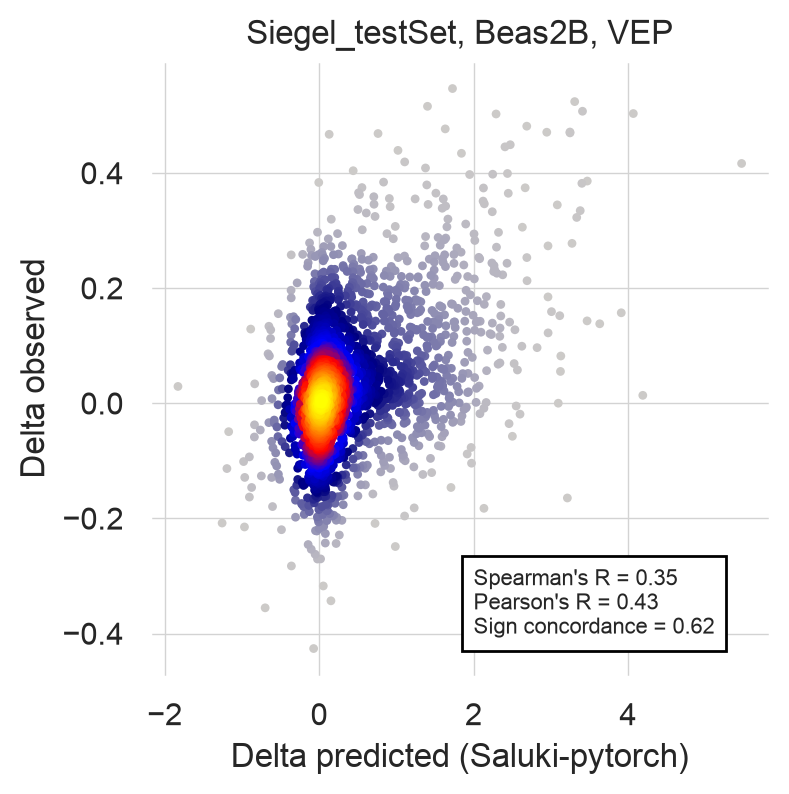

In [473]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x = df_j['delta_pred_pytorch'].values
y = df_j['measured'].values
xy = np.vstack([x, y]) 
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx] 

fig, ax = plt.subplots(figsize=(4, 4), dpi=200) 
sc = ax.scatter( x, y, c=z, s=10, cmap=cmap, edgecolors='none', alpha=1 ) 
ax.set_facecolor('white') 
ax.grid(True, color='lightgray', linewidth=0.5) 
plt.xlabel('Delta predicted (Saluki-pytorch)') 
plt.ylabel('Delta observed') 
plt.title(f"Siegel_testSet, {cell_line}, VEP")
plt.text(2, -0.4, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}\nSign concordance = {sign_concordance(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))
plt.show()

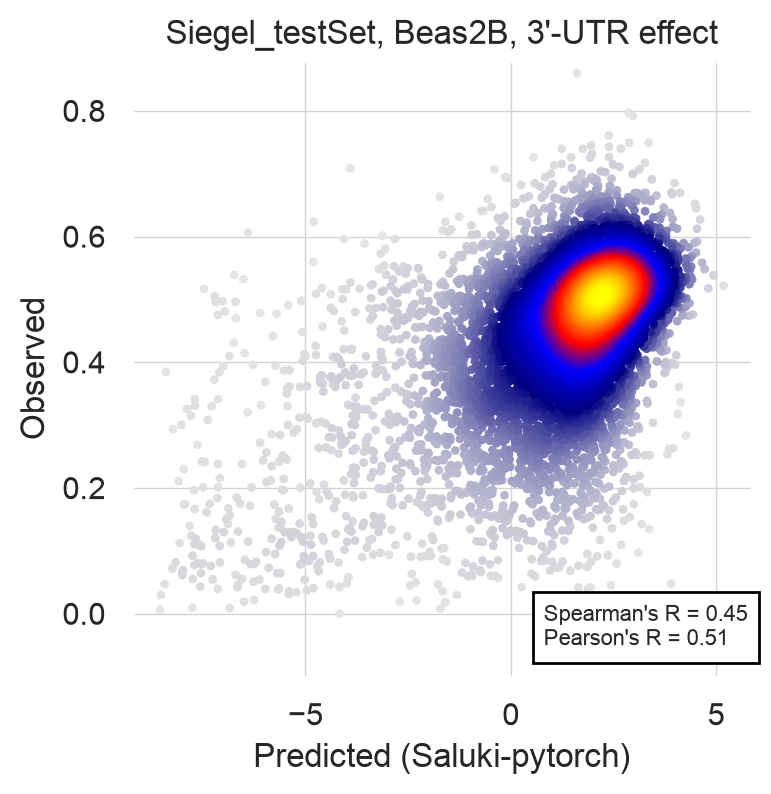

In [341]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x = df_beas2b_utr['pred'].values # pytorch
y = df_beas2b_utr['measured_beas2b'].values

xy = np.vstack([x, y]) 
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx] 

fig, ax = plt.subplots(figsize=(4, 4), dpi=200) 
sc = ax.scatter( x, y, c=z, s=10, cmap=cmap, edgecolors='none', alpha=1 ) 
ax.set_facecolor('white') 
ax.grid(True, color='lightgray', linewidth=0.5) 
plt.xlabel('Predicted (Saluki-pytorch)') 
plt.ylabel('Observed') 
plt.ylim((-0.1, 0.88))
plt.title(f"Siegel_testSet, Beas2B, 3'-UTR effect")
plt.text(0.8, -0.05, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))
plt.show()

In [124]:
df_mpras_jurkat = pd.read_table(mpra_data_path+f"fastUTR_mpra_Jurkat.txt.gz", header=None, compression='gzip')
df_mpras_beas2b = pd.read_table(mpra_data_path+f"fastUTR_mpra_Beas2B.txt.gz", header=None, compression='gzip')
df_mpras_no_suff = pd.read_table(mpra_data_path+f"fastUTR_mpra.txt.gz", header=None, compression='gzip')

In [525]:
# df_all_joined.to_csv('df_all_joined_test.csv')
# df_j_mouse_preds.to_csv('df_j_mouse_preds_test.csv')
# df_toga_val.to_csv('df_toga_val_test.csv')
# df_j.to_csv('df_j_val.csv')
# df_beas2b_utr.to_csv('df_beas2b_utr.csv')

In [515]:
# df_all_joined = pd.read_csv('df_all_joined_test.csv')
# df_j_mouse_preds = pd.read_csv('df_j_mouse_preds_test.csv')
# df_j = pd.read_csv('df_j_val.csv')
# df_beas2b_utr = pd.read_csv('df_beas2b_utr.csv')

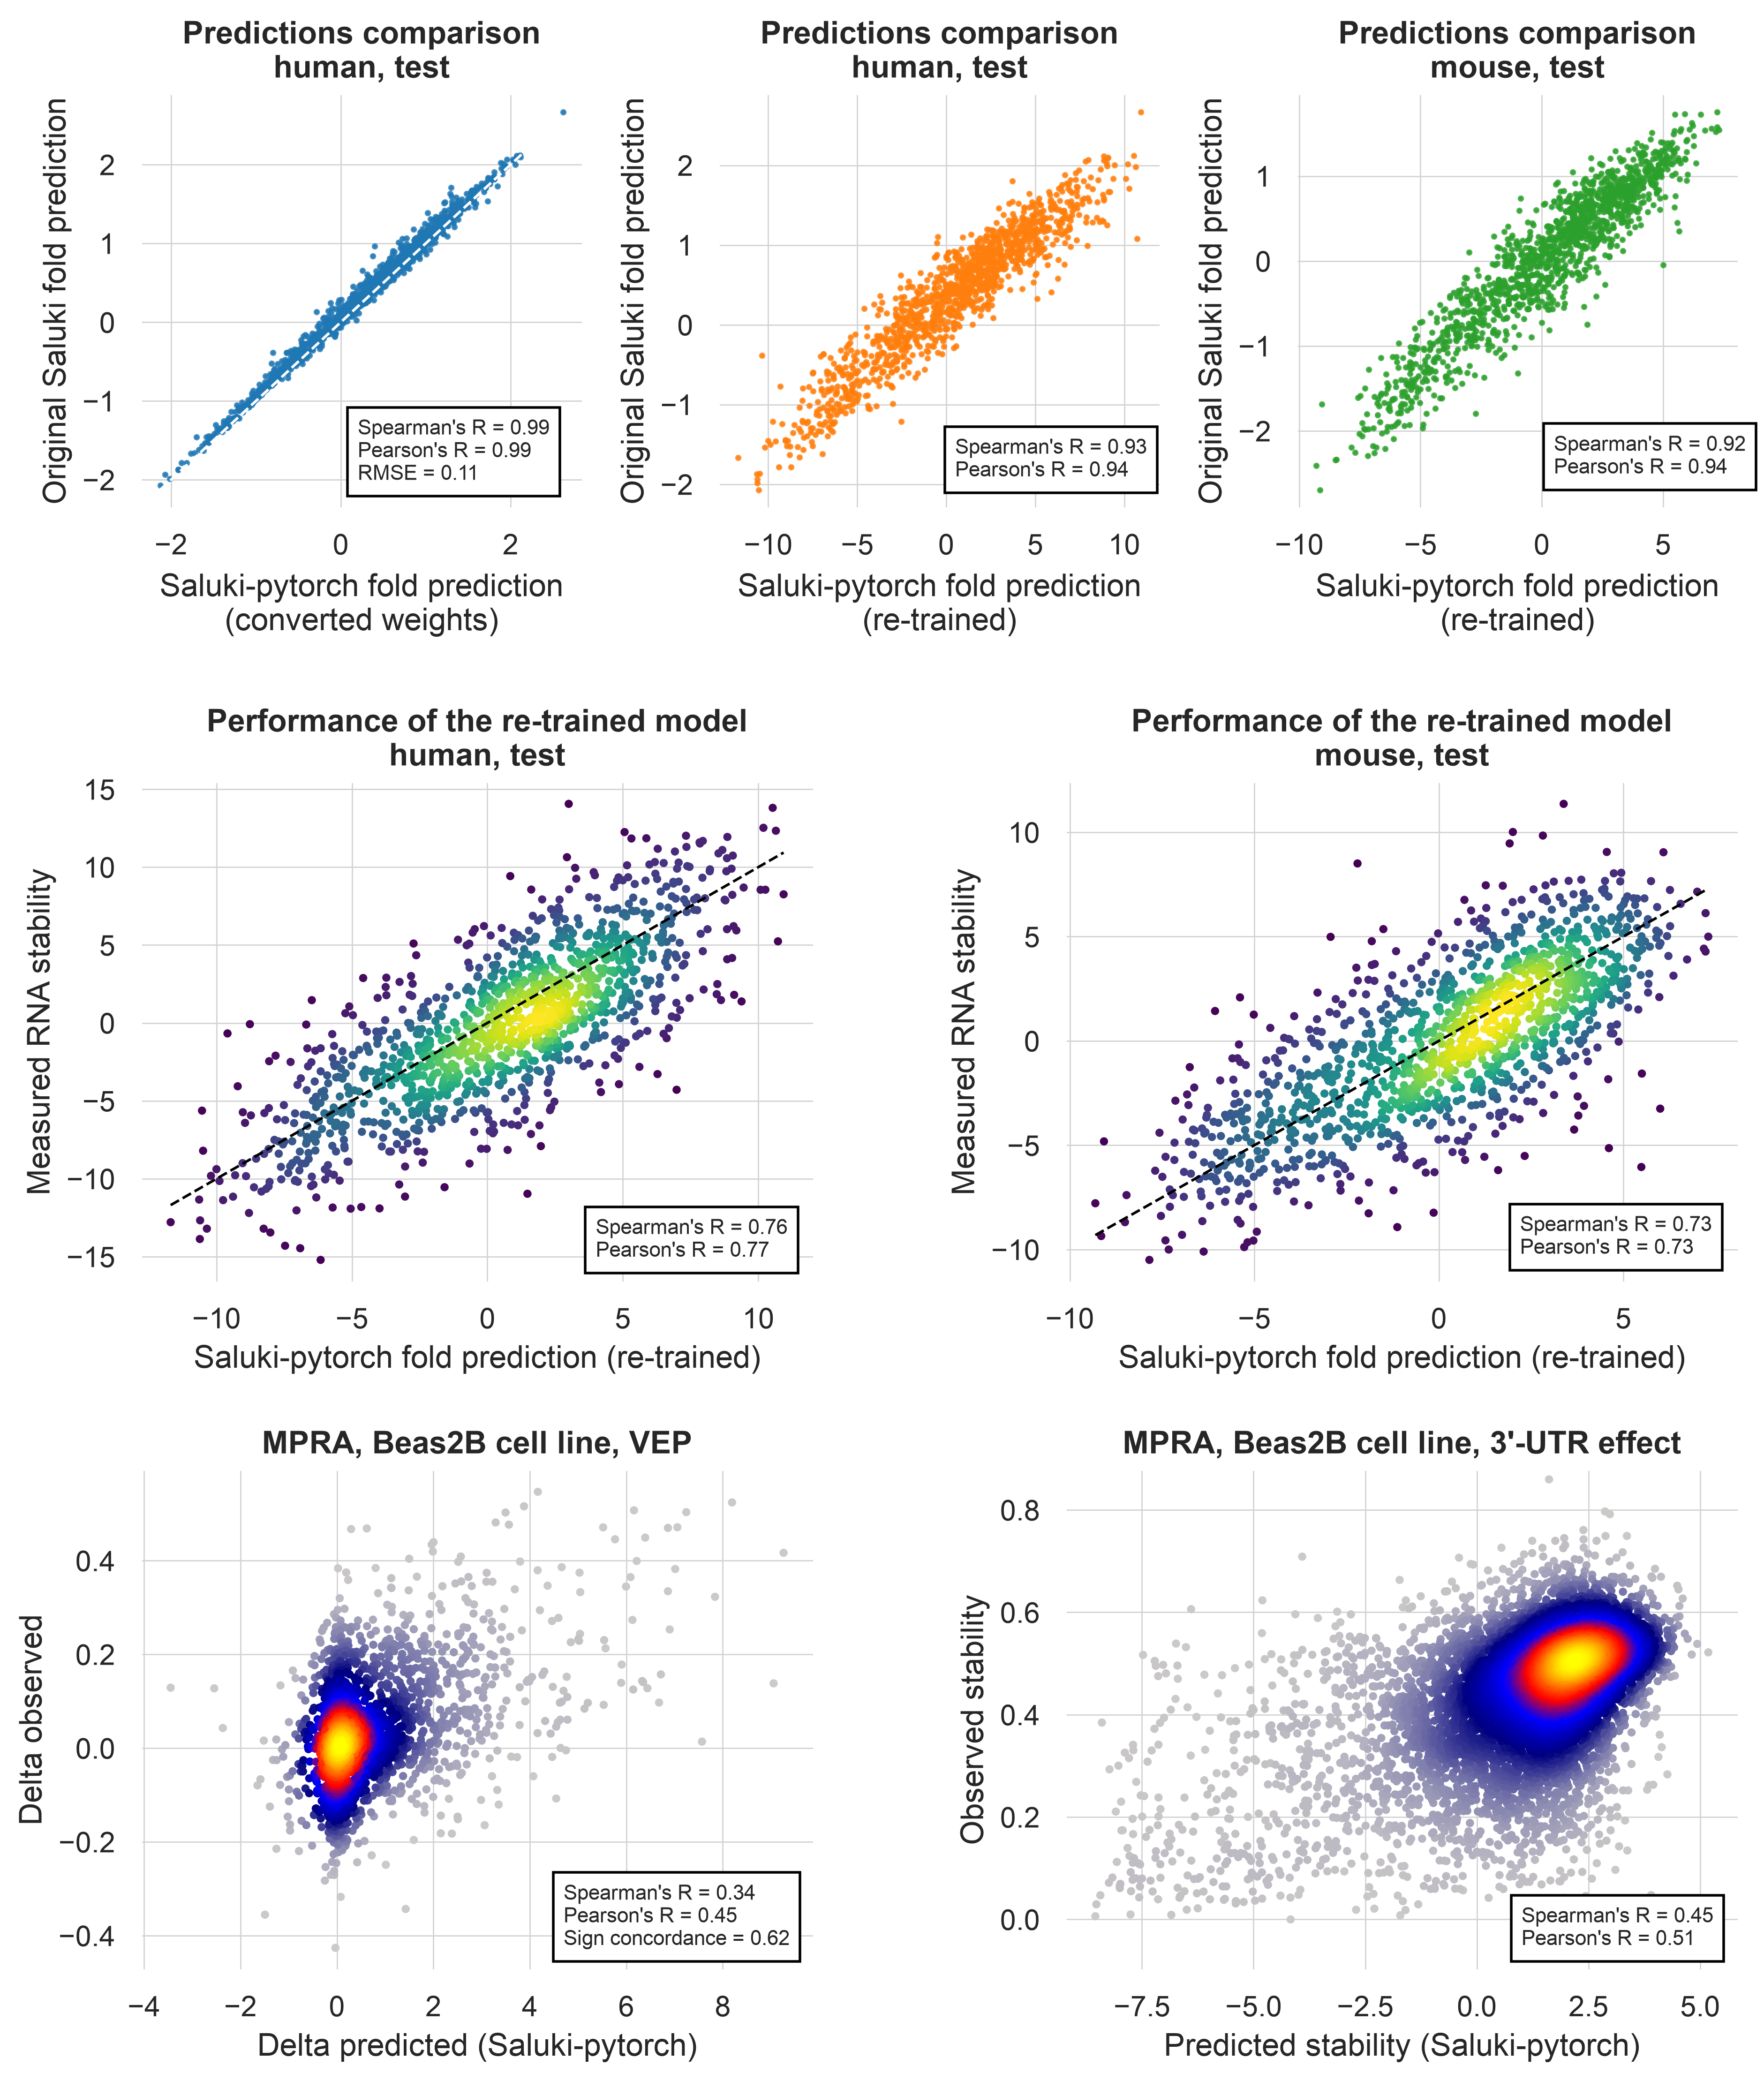

<Figure size 640x480 with 0 Axes>

In [528]:
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec

fold = 'test'

fig = plt.figure(figsize=(11, 13), dpi=400)
gs = GridSpec(22, 14, figure=fig)

ax1 = fig.add_subplot(gs[0:5, 0:4])
ax2 = fig.add_subplot(gs[0:5, 5:9])
ax3 = fig.add_subplot(gs[0:5, 10:14])

ax4 = fig.add_subplot(gs[8:14, 0:6])
ax5 = fig.add_subplot(gs[8:14, 8:14])

ax6 = fig.add_subplot(gs[16:22, 0:6])
ax7 = fig.add_subplot(gs[16:22, 8:14])

x = df_all_joined['saluki_pytorch_pred_converted'].values
y = df_all_joined['orig_saluki_pred'].values
sc = ax1.scatter(x, y, alpha=0.8, s=2, color='tab:blue') 
ax1.plot([x.min(), x.max()], [x.min(), x.max()], linestyle='--', linewidth=1, color='white')
ax1.set_facecolor('white') 
ax1.grid(True, color='lightgray', linewidth=0.5) 
ax1.set_xlabel('Saluki-pytorch fold prediction\n(converted weights)') 
ax1.set_ylabel('Original Saluki fold prediction') 
ax1.set_title(f"Predictions comparison\nhuman, {fold}", fontweight="bold")
ax1.text(0.2, -2, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}\nRMSE = {root_mean_squared_error(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))

x = df_all_joined['saluki_pytorch_pred_2species'].values
y = df_all_joined['orig_saluki_pred'].values
sc = ax2.scatter(x, y, alpha=0.8, s=2, color='tab:orange') 
ax2.set_facecolor('white') 
ax2.grid(True, color='lightgray', linewidth=0.5) 
ax2.set_xlabel('Saluki-pytorch fold prediction\n(re-trained)') 
ax2.set_ylabel('Original Saluki fold prediction') 
ax2.set_title(f"Predictions comparison\nhuman, {fold}", fontweight="bold")
ax2.text(0.5, -1.9, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))

x = df_j_mouse_preds['saluki_pytorch_pred'].values
y = df_j_mouse_preds['orig_saluki_pred'].values
sc = ax3.scatter(x, y, alpha=0.8, s=2, color='tab:green') 
ax3.set_facecolor('white') 
ax3.grid(True, color='lightgray', linewidth=0.5) 
ax3.set_xlabel('Saluki-pytorch fold prediction\n(re-trained)') 
ax3.set_ylabel('Original Saluki fold prediction') 
ax3.set_title(f"Predictions comparison\nmouse, {fold}", fontweight="bold")
ax3.text(0.5, -2.5, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))

x = df_all_joined['saluki_pytorch_pred_2species'].values
y = df_all_joined['half_life'].values
xy = np.vstack([x, y]) 
z = gaussian_kde(xy)(xy)
idx = z.argsort()
x, y, z = x[idx], y[idx], z[idx]  
sc = ax4.scatter( x, y, c=z, s=10, cmap='viridis', edgecolors='none', alpha=1 ) 
ax4.plot([x.min(), x.max()], [x.min(), x.max()], linestyle='--', color='black', linewidth=1)
ax4.set_facecolor('white') 
ax4.grid(True, color='lightgray', linewidth=0.5) 
ax4.set_xlabel('Saluki-pytorch fold prediction (re-trained)') 
ax4.set_ylabel('Measured RNA stability')
ax4.set_title(f"Performance of the re-trained model\nhuman, {fold}", fontweight="bold")
ax4.text(4, -15, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))

x = df_toga_val['saluki_pytorch_pred'].values
y = df_toga_val['half_life'].values
xy = np.vstack([x, y]) 
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx]  
sc = ax5.scatter( x, y, c=z, s=10, cmap='viridis', edgecolors='none', alpha=1 ) 
ax5.plot([x.min(), x.max()], [x.min(), x.max()], linestyle='--', color='black', linewidth=1)
ax5.set_facecolor('white') 
ax5.grid(True, color='lightgray', linewidth=0.5) 
ax5.set_xlabel('Saluki-pytorch fold prediction (re-trained)') 
ax5.set_ylabel('Measured RNA stability')
ax5.set_title(f"Performance of the re-trained model\nmouse, {fold}", fontweight="bold")
ax5.text(2.2, -10.2, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))

x = df_j['delta_pred_pytorch'].values
y = df_j['measured'].values
xy = np.vstack([x, y]) 
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx]  
sc = ax6.scatter( x, y, c=z, s=10, cmap=cmap, edgecolors='none', alpha=1 ) 
ax6.set_facecolor('white') 
ax6.grid(True, color='lightgray', linewidth=0.5) 
ax6.set_xlabel('Delta predicted (Saluki-pytorch)') 
ax6.set_ylabel('Delta observed') 
ax6.set_title(f"MPRA, Beas2B cell line, VEP", fontweight="bold")
ax6.text(4.7, -0.42, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}\nSign concordance = {sign_concordance(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))

x = df_beas2b_utr['pred'].values # pytorch
y = df_beas2b_utr['measured_beas2b'].values
xy = np.vstack([x, y]) 
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx] 
sc = ax7.scatter( x, y, c=z, s=10, cmap=cmap, edgecolors='none', alpha=1 ) 
ax7.set_facecolor('white') 
ax7.grid(True, color='lightgray', linewidth=0.5) 
ax7.set_xlabel('Predicted stability (Saluki-pytorch)') 
ax7.set_ylabel('Observed stability') 
ax7.set_ylim((-0.1, 0.88))
ax7.set_title(f"MPRA, Beas2B cell line, 3'-UTR effect", fontweight="bold")
plt.text(1.0, -0.05, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))
plt.show()

plt.tight_layout()
fig.savefig('figure_1_raw.png', dpi=300)
plt.show()

In [353]:
df_toga_val

,chrom,start,end,strand,gene,fold,start_cds,end_cds,block_count,block_sizes,block_starts,block_count_cds,block_sizes_cds,block_starts_cds,half_life,seq,frame,splice,saluki_pytorch_pred
9,chr11,85886421,85916095,+,ENSMUSG00000000094,1,85890062,85914745,9,"141,204,95,120,148,153,89,236,1967,","0,3638,4435,12071,13328,24685,25514,25684,27707,",8,"201,95,120,148,153,89,236,617,","0,794,8430,9687,21044,21873,22043,24066,",-0.430318,GCTGGGCCCCGAGGGCGCAGCAGGCAGCCGGACGGTGACCCAGAGG...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,-4.397461
19,chr7,143475100,143499325,+,ENSMUSG00000000154,1,143476197,143499272,11,"138,236,98,161,133,113,108,101,102,121,241,","0,969,4184,4619,5289,15711,16645,17741,21850,2...",10,"108,98,161,133,113,108,101,102,121,188,","0,3087,3522,4192,14614,15548,16644,20753,21112...",3.104441,ATTGTGGGGTGGGACCTTTCCGGGTCACTAAGGAAGGGCCTCTATC...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,3.066014
31,chr11,55514237,55607821,-,ENSMUSG00000000263,1,55514812,55607733,9,"890,147,215,138,83,224,68,128,144,","0,6684,13017,18046,19586,22043,51971,60044,93440,",9,"315,147,215,138,83,224,68,128,56,","0,6109,12442,17471,19011,21468,51396,59469,92865,",2.129641,AGTGGCGCTCTCTGGCTTCGTAAGTGCCCATCGAAAACATTTTTGC...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,4.100743
33,chr11,88999375,89020293,+,ENSMUSG00000000275,1,88999488,89016721,9,"707,96,234,169,63,24,99,99,4099,","0,5353,9743,11429,14100,15791,16157,16343,16819,",9,"594,96,234,169,63,24,99,99,527,","0,5240,9630,11316,13987,15678,16044,16230,16706,",-3.726447,AGGGCGCCGCCCCTCCTGTTCAGTTTCGATTCCTTCCTCGCTGCTT...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,-3.264026
42,chr2,179442430,179899373,+,ENSMUSG00000000305,1,179442621,179895918,16,"248,112,227,171,156,145,173,138,186,254,143,23...","0,2269,337823,355027,400538,404789,417686,4316...",16,"57,112,227,171,156,145,173,138,186,254,143,234...","0,2078,337632,354836,400347,404598,417495,4314...",2.108317,GAACAGAGGCGCGGGCGGCTGCGAGGCCGGCGGACGCACCGGCCGG...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,2.356611
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
13608,chr18,37707038,37841873,+,ENSMUSG00000103793,1,37707228,37840129,4,"2614,59,89,1971,","0,117982,126226,132864,",4,"2424,59,89,227,","0,117792,126036,132674,",2.950321,GGTTGTGTCATGTTAAAATACCAAACCTATGCAAAAAAGAAAAAGA...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,1.837826
13614,chr5,31156520,31180117,-,ENSMUSG00000106864,1,31157548,31174472,21,"1247,108,153,129,88,162,145,130,26,109,112,228...","0,1622,1822,2540,2913,3179,3427,9365,9840,1117...",19,"219,108,153,129,88,162,145,130,26,109,112,228,...","0,594,794,1512,1885,2151,2399,8337,8812,10147,...",-0.720919,CGGAAGCCACGCTCCAGCTCGCGGGCGTCGGAGGGCTCAGTGCCGC...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,-0.691645
13626,chr7,28399521,28436191,-,ENSMUSG00000109336,1,28401588,28423631,13,"2096,84,124,199,119,86,319,87,110,240,471,402,54,","0,2302,4098,4342,5967,6432,6847,7709,7947,8414...",12,"29,84,124,199,119,86,319,87,110,240,471,196,","0,235,2031,2275,3900,4365,4780,5642,5880,6347,...",0.983949,CGGCGGCTGCCCGAGGAGGTGCGGGTGGCGGCGGCGGCGGCGGAGG...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,1.360039
13632,chr8,111056338,111057664,+,ENSMUSG00000109941,1,111056370,111057192,1,"1326,","0,",1,"822,","0,",-5.131030,AGGCGGAAGTAGCTCGCACGCCGGTAGCCGCCATGCCGGGAGACCA...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNXNNXNNXNNXNNXN...,NNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNNN...,-7.613823


# CR

In [694]:
# Human-only
checkpoint_path = '/Users/neverovaleksandr/saluki/project-half-life/outputs/out_setup_1sp/local_07-11-16-54/model_best_local_07-11-16-54.pt'

In [695]:
device = 'cuda' if torch.cuda.is_available() else 'mps' if torch.mps.is_available() else 'cuda'
# device = 'cpu'
print(device)

mps


In [696]:
model = SalukiModel(heads=1)
if 'weights_converted' in checkpoint_path:
    import pickle
    with open(checkpoint_path, "rb") as f:
        checkpoint = pickle.load(f)
    for key in checkpoint.keys():
        checkpoint[key] = torch.from_numpy(checkpoint[key])
    model.load_state_dict(checkpoint)
else:
    model.load_state_dict(torch.load(checkpoint_path, weights_only=True, map_location=device))
model.eval()
model.to(device)

SalukiModel(
  (initial_conv): Conv1d(6, 64, kernel_size=(5,), stride=(1,), bias=False)
  (middle_blocks): ModuleList(
    (0-5): 6 x ModuleDict(
      (ln): LayerNorm((64,), eps=0.007, elementwise_affine=True, bias=True)
      (conv): Conv1d(64, 64, kernel_size=(5,), stride=(1,))
      (dropout): Dropout(p=0.3, inplace=False)
      (pool): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
  )
  (gru_ln): LayerNorm((64,), eps=0.007, elementwise_affine=True, bias=True)
  (gru): GRU(64, 64, batch_first=True)
  (penultimate_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, bias=True, track_running_stats=True)
  (penultimate_dense): Linear(in_features=64, out_features=64, bias=True)
  (penultimate_dropout): Dropout(p=0.3, inplace=False)
  (final_bn): BatchNorm1d(64, eps=0.001, momentum=0.09999999999999998, affine=True, bias=True, track_running_stats=True)
  (output_heads): ModuleList(
    (0): Linear(in_features=64, out_features=1, bi

In [697]:
train_data, eval_data, test_data = create_saluki_dataloaders(
    species_tsvs={
        "human": "../project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv",
        "mouse": "../project03/toga_13_species_updated/saluki_mouse.mm10.mm10.tsv"},
    species_order=['human', 'mouse'],
    batch_size=64,
    seq_length=12288,
    num_workers=0,
    drop_last=False,
    include_test=True
) 

In [698]:
df_human = pd.read_table("../project03/toga_13_species_updated/saluki_human.hg38.hg38.tsv")
df_mouse = pd.read_table("../project03/toga_13_species_updated/saluki_mouse.mm10.mm10.tsv")

df_human_val = df_human[df_human['fold'].isin([1])].copy()
df_human_test = df_human[df_human['fold'].isin([0])].copy()
df_mouse_val = df_mouse[df_mouse['fold'].isin([1])].copy()
df_mouse_test = df_mouse[df_mouse['fold'].isin([0])].copy()

In [699]:
species_i = 0

all_outputs_val, all_targets_val = [], []

with torch.no_grad():
    for x, y_true in tqdm(eval_data[species_i], total=len(eval_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x, species_index=0)
    
        all_targets_val.append(y_true.clone().squeeze())
        all_outputs_val.append(y_pred.cpu().clone().squeeze())

all_outputs_val, all_targets_val = torch.hstack(all_outputs_val), torch.hstack(all_targets_val)

all_outputs_test, all_targets_test = [], []

with torch.no_grad():
    for x, y_true in tqdm(test_data[species_i], total=len(test_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x, species_index=0)
    
        all_targets_test.append(y_true.clone().squeeze())
        all_outputs_test.append(y_pred.cpu().clone().squeeze())

all_outputs_test, all_targets_test = torch.hstack(all_outputs_test), torch.hstack(all_targets_test)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 20/20 [00:02<00:00,  9.05it/s]


In [700]:
df_human_val['saluki_pred'] = all_outputs_val
df_human_val['saluki_target'] = all_targets_val
df_human_test['saluki_pred'] = all_outputs_test
df_human_test['saluki_target'] = all_targets_test

In [701]:
species_i = 1

all_outputs_val, all_targets_val = [], []

with torch.no_grad():
    for x, y_true in tqdm(eval_data[species_i], total=len(eval_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x, species_index=0)
    
        all_targets_val.append(y_true.clone().squeeze())
        all_outputs_val.append(y_pred.cpu().clone().squeeze())

all_outputs_val, all_targets_val = torch.hstack(all_outputs_val), torch.hstack(all_targets_val)

all_outputs_test, all_targets_test = [], []

with torch.no_grad():
    for x, y_true in tqdm(test_data[species_i], total=len(test_data[species_i])):
        x = x.to(device, dtype=torch.float32)
        y_pred = model(x, species_index=0)
    
        all_targets_test.append(y_true.clone().squeeze())
        all_outputs_test.append(y_pred.cpu().clone().squeeze())

all_outputs_test, all_targets_test = torch.hstack(all_outputs_test), torch.hstack(all_targets_test)

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 22/22 [00:02<00:00,  9.50it/s]


In [702]:
df_mouse_val['saluki_pred'] = all_outputs_val
df_mouse_val['saluki_target'] = all_targets_val
df_mouse_test['saluki_pred'] = all_outputs_test
df_mouse_test['saluki_target'] = all_targets_test

In [704]:
assert np.allclose(df_mouse_val['half_life'].to_numpy(), df_mouse_val['saluki_target'].to_numpy())
assert np.allclose(df_mouse_test['half_life'].to_numpy(), df_mouse_test['saluki_target'].to_numpy())
assert np.allclose(df_human_val['half_life'].to_numpy(), df_human_val['saluki_target'].to_numpy())
assert np.allclose(df_human_test['half_life'].to_numpy(), df_human_test['saluki_target'].to_numpy())

In [705]:
df_mouse = pd.concat([df_mouse_val, df_mouse_test])
df_human = pd.concat([df_human_val, df_human_test])

In [706]:
df_orthologs = pd.read_table('OMA-Pairs_HUMAN-MOUSE_2026-01-14_171915.tsv')

In [707]:
df_orthologs = df_orthologs[df_orthologs['RelType'] == '1:1'].copy()

In [708]:
df_orthologs['Ensembl Gene_1'] = df_orthologs['Ensembl Gene_1'].apply(lambda x: x.split('.')[0])
df_orthologs['Ensembl Gene_2'] = df_orthologs['Ensembl Gene_2'].apply(lambda x: x.split('.')[0])

In [709]:
df_orthologs = df_orthologs[['Ensembl Gene_1', 'Ensembl Gene_2']].rename(columns={
    'Ensembl Gene_1': 'gene_id_human',
    'Ensembl Gene_2': 'gene_id_mouse'
})

In [710]:
df_joined = df_orthologs.set_index('gene_id_human').join(
    df_human.rename(columns={'gene': 'gene_id_human'}).set_index('gene_id_human')
).reset_index().set_index('gene_id_mouse').join(
    df_mouse.rename(columns={'gene': 'gene_id_mouse'}).set_index('gene_id_mouse'), lsuffix='_human', rsuffix='_mouse'
).reset_index()

In [712]:
df_joined_clean = df_joined[
    (~df_joined['half_life_human'].isna())
    &
    (~df_joined['half_life_mouse'].isna())
].copy()

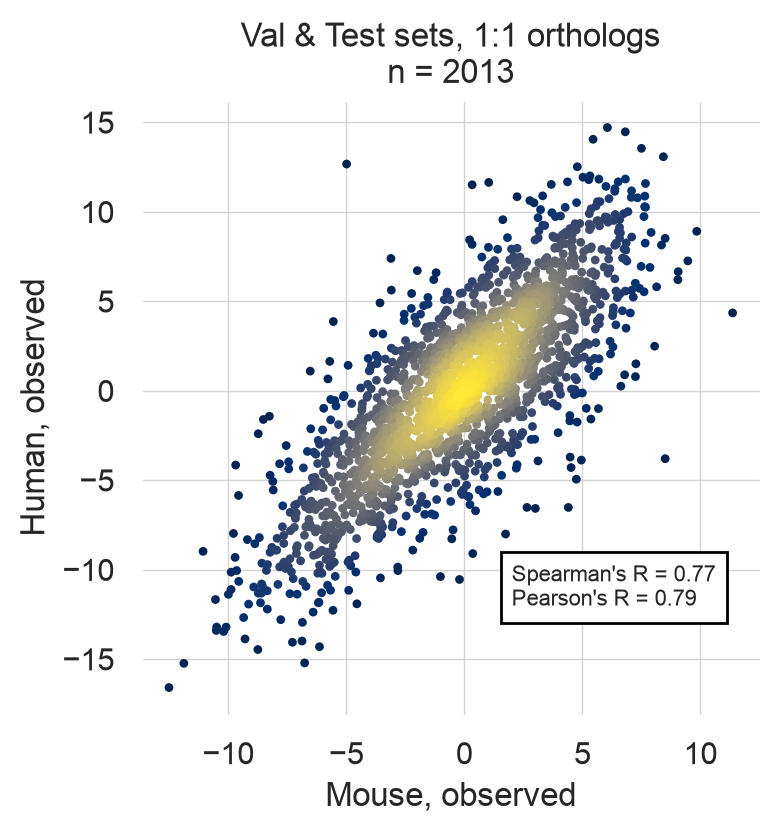

In [713]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x = df_joined_clean['half_life_mouse'].values
y = df_joined_clean['half_life_human'].values

xy = np.vstack([x, y]) 
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx] 

fig, ax = plt.subplots(figsize=(4, 4), dpi=200) 
sc = ax.scatter( x, y, c=z, s=10, cmap='cividis', edgecolors='none', alpha=1 ) 
ax.set_facecolor('white') 
ax.grid(True, color='lightgray', linewidth=0.5) 
plt.xlabel('Mouse, observed')  
plt.ylabel('Human, observed')

plt.title(f"Val & Test sets, 1:1 orthologs\nn = {len(x)}")
plt.text(2, -12, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))
plt.show()

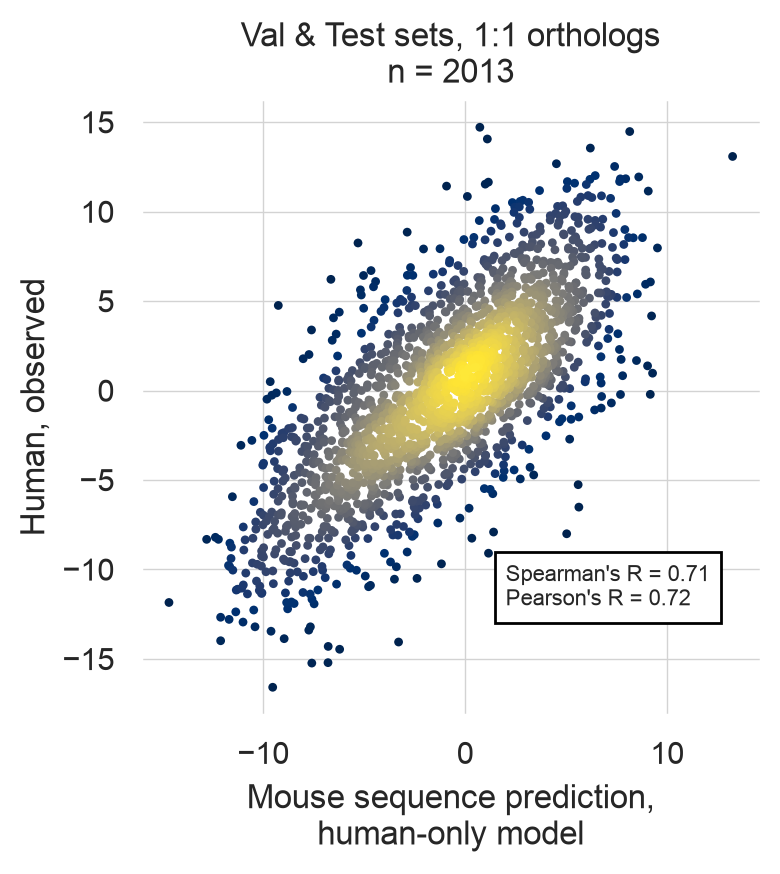

In [715]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x = df_joined_clean['saluki_pred_mouse'].values
y = df_joined_clean['half_life_human'].values

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx] 

fig, ax = plt.subplots(figsize=(4, 4), dpi=200) 
sc = ax.scatter( x, y, c=z, s=10, cmap='cividis', edgecolors='none', alpha=1 ) 
ax.set_facecolor('white') 
ax.grid(True, color='lightgray', linewidth=0.5) 

plt.xlabel('Mouse sequence prediction,\nhuman-only model')  
plt.ylabel('Human, observed')

plt.title(f"Val & Test sets, 1:1 orthologs\nn = {len(x)}")
plt.text(2, -12, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))
plt.show()

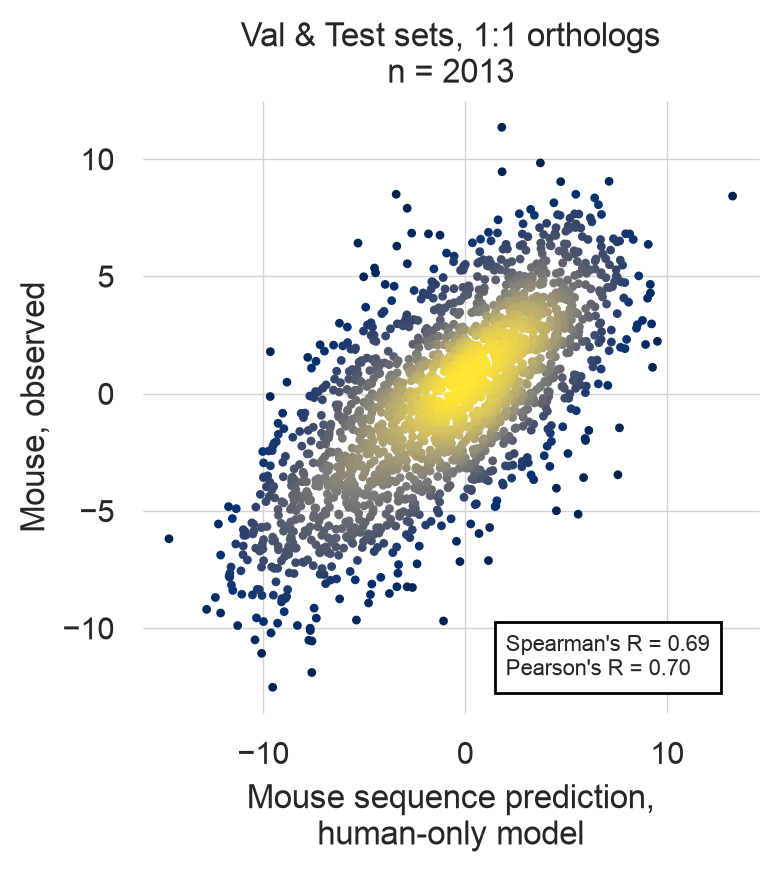

In [716]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

x = df_joined_clean['saluki_pred_mouse'].values
y = df_joined_clean['half_life_mouse'].values

xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
idx = z.argsort() 
x, y, z = x[idx], y[idx], z[idx] 

fig, ax = plt.subplots(figsize=(4, 4), dpi=200) 
sc = ax.scatter( x, y, c=z, s=10, cmap='cividis', edgecolors='none', alpha=1 ) 
ax.set_facecolor('white') 
ax.grid(True, color='lightgray', linewidth=0.5) 

plt.xlabel('Mouse sequence prediction,\nhuman-only model')  
plt.ylabel('Mouse, observed')

plt.title(f"Val & Test sets, 1:1 orthologs\nn = {len(x)}")
plt.text(2, -12, f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}", fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))
plt.show()

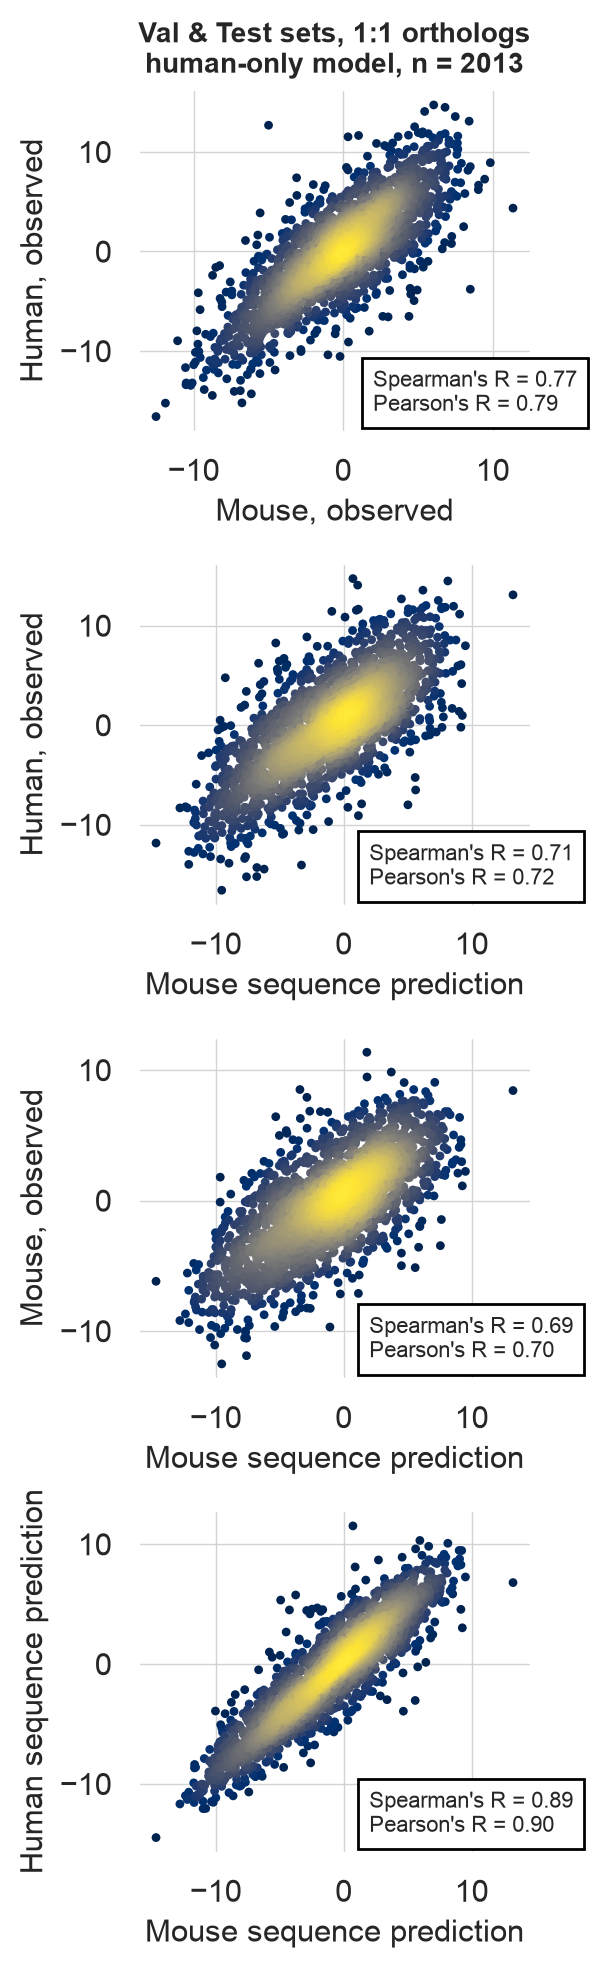

In [725]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde

# --- 1. Define data configurations ---
# Format: (x_column, y_column, x_label, y_label)
plot_configs = [
    ('half_life_mouse', 'half_life_human', 'Mouse, observed', 'Human, observed'),
    ('saluki_pred_mouse', 'half_life_human', 'Mouse sequence prediction', 'Human, observed'),
    ('saluki_pred_mouse', 'half_life_mouse', 'Mouse sequence prediction', 'Mouse, observed'),
    ('saluki_pred_mouse', 'saluki_pred_human', 'Mouse sequence prediction', 'Human sequence prediction')
]

# --- 2. Initialize the combined figure ---
# 1 row, 3 columns. Adjusted figsize for a side-by-side layout.
fig, axes = plt.subplots(4, 1, figsize=(3, 10), dpi=200, sharey=False)

# --- 3. Plot each dataset ---
for i, (x_col, y_col, x_label, y_label) in enumerate(plot_configs):
    ax = axes[i]
    
    # Extract data
    x = df_joined_clean[x_col].values
    y = df_joined_clean[y_col].values
    
    # Calculate density for color mapping
    xy = np.vstack([x, y]) 
    z = gaussian_kde(xy)(xy)
    idx = z.argsort() 
    x, y, z = x[idx], y[idx], z[idx] 
    
    # Scatter plot
    sc = ax.scatter(x, y, c=z, s=10, cmap='cividis', edgecolors='none', alpha=1) 
    
    # Styling and Grid
    ax.set_facecolor('white') 
    ax.grid(True, color='lightgray', linewidth=0.5) 
    ax.set_xlabel(x_label, fontsize=11)  
    ax.set_ylabel(y_label, fontsize=11)
    
    # Titles and Annotations
    if i == 0:
        ax.set_title(f"Val & Test sets, 1:1 orthologs\nhuman-only model, n = {len(x)}", fontsize=10, fontweight="bold")
    
    # Stats text box
    stats_text = f"Spearman's R = {spearman(x, y):.2f}\nPearson's R = {pearson(x, y):.2f}"
    ax.text(2, -16+4*(i==2)+2*(i==3), stats_text, fontsize=8, bbox=dict(facecolor="white", edgecolor="black", alpha=1.0))

plt.tight_layout()
fig.savefig('figure_CR.png', dpi=300)
plt.show()